In [24]:
import pandas as pd
import geopandas as gpd
import contextily as ctx

<Axes: >

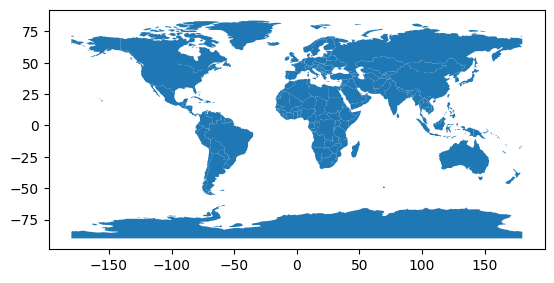

In [25]:
url="C:\\Users\\KARUN NAGARAJ\\Downloads\\ne_110m_admin_0_countries"
world_gdf= gpd.read_file(url)
world_gdf.plot()


In [26]:
world_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [27]:
print(world_gdf.crs)

EPSG:4326


In [28]:
world_gdf['pop_density']= world_gdf.POP_EST / world_gdf.area*1000000
world_gdf.sort_values('pop_density', ascending=False).head()


C:\Users\KARUN NAGARAJ\AppData\Local\Temp\ipykernel_1956\840736323.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_gdf['pop_density']= world_gdf.POP_EST / world_gdf.area*1000000


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,pop_density
99,Admin-0 country,1,3,Bangladesh,BGD,0,2,Sovereign country,1,Bangladesh,...,None,None,None,None,None,None,None,None,"POLYGON ((92.67272 22.04124, 92.65226 21.32405...",1.375084e+13
79,Admin-0 country,1,5,Israel,IS1,1,2,Indeterminate,1,Palestine,...,None,None,None,None,None,None,Admin-0 country,None,"POLYGON ((35.39756 31.48909, 34.92741 31.35344...",9.754682e+12
140,Admin-0 country,1,3,Taiwan,TWN,0,2,Sovereign country,1,Taiwan,...,Admin-1 states provinces,None,None,None,None,None,Admin-1 states provinces,None,"POLYGON ((121.77782 24.39427, 121.17563 22.790...",7.744572e+12
77,Admin-0 country,1,5,Lebanon,LBN,0,2,Sovereign country,1,Lebanon,...,None,None,None,None,None,None,None,None,"POLYGON ((35.8211 33.27743, 35.5528 33.26427, ...",6.968534e+12
169,Admin-0 country,1,3,Rwanda,RWA,0,2,Sovereign country,1,Rwanda,...,None,None,None,None,None,None,None,None,"POLYGON ((30.4191 -1.13466, 30.81613 -1.69891,...",6.647863e+12


<Axes: >

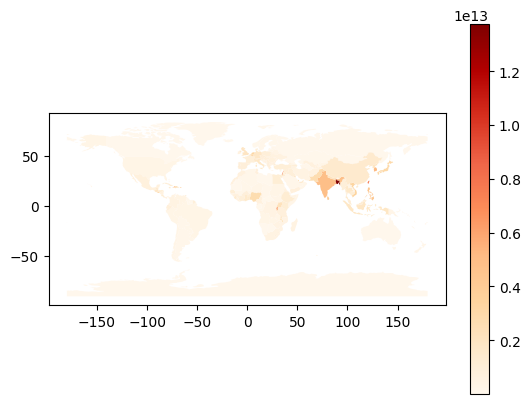

In [29]:
world_gdf.plot("pop_density", cmap="OrRd", legend=True)

In [30]:
norm=matplotlib.colors.LogNorm(vmin=world_gdf.pop_density.min(), vmax=world_gdf.pop_density.max())
world_gdf.to_crs('epsg=3857').plot(column="pop_density", cmap="OrRd", legend=True, norm=norm)

NameError: name 'matplotlib' is not defined

In [40]:
#download shape file of karnataka from https://kgis.ksrsac.in/kgis/downloads.aspx?authuser=1 and put it in the same directory
gdf_districts=gpd.read_file("./State/State.shp")
gdf_districts.head(5)

,KGISStateI,KGISStateC,KGISStateN,created_us,created_da,last_edite,last_edi_1,SHAPE_STAr,SHAPE_STLe,geometry
0,1,29,Karnataka,None,NaT,SURESHBV1,2022-12-02,1.918512e+11,4.777528e+06,"MULTIPOLYGON (((530654.289 1394659.955, 530651..."


In [4]:
import geopandas as gpd
gdf_districts=gpd.read_file(r"C:\Users\KARUN NAGARAJ\Downloads\advanced python\District\District.shp")
gdf_districts.head(5)

,KGISDistri,LGD_Distri,KGISDist_1,BhuCodeDis,created_us,created_da,last_edite,last_edi_1,SHAPE_STAr,SHAPE_STLe,geometry
0,01,527,Belagavi,01,None,NaT,SURESHBV1,2022-11-24,1.339772e+10,1.141488e+06,"MULTIPOLYGON (((537523.31 1865366.861, 537555...."
1,02,524,Bagalkot,02,None,NaT,SURESHBV1,2022-09-08,6.561826e+09,6.682456e+05,"POLYGON ((581917.898 1811433.959, 581946.875 1..."
2,03,530,Vijayapura,03,None,NaT,SURESHBV1,2022-11-24,1.050271e+10,7.032618e+05,"POLYGON ((537523.31 1865366.861, 537516.168 18..."
3,04,538,Kalburgi,04,None,NaT,SURESHBV1,2022-11-09,1.097395e+10,9.181459e+05,"MULTIPOLYGON (((680992.661 1951255.947, 681227..."
4,05,529,Bidar,05,None,NaT,SURESHBV1,2022-11-16,5.454415e+09,5.733925e+05,"MULTIPOLYGON (((766506.612 1970249.909, 766481..."


<Axes: >

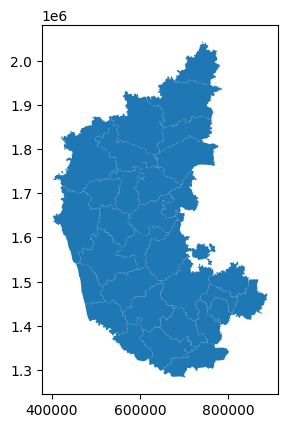

In [42]:
gdf_districts.plot()

In [1]:
import pandas as pd
df=pd.read_csv("C:\\Users\\KARUN NAGARAJ\\Downloads\\Karnataka-DistPop1.csv")


In [7]:
gdf_merged=gdf_districts.merge(df,left_on='KGISDist_1', right_on='District', how='left')
gdf_merged.head(5)

,KGISDistri,LGD_Distri,KGISDist_1,BhuCodeDis,created_us,created_da,last_edite,last_edi_1,SHAPE_STAr,SHAPE_STLe,geometry,District,population
0,01,527,Belagavi,01,None,NaT,SURESHBV1,2022-11-24,1.339772e+10,1.141488e+06,"MULTIPOLYGON (((537523.31 1865366.861, 537555....",Belagavi,100481
1,02,524,Bagalkot,02,None,NaT,SURESHBV1,2022-09-08,6.561826e+09,6.682456e+05,"POLYGON ((581917.898 1811433.959, 581946.875 1...",Bagalkot,83973
2,03,530,Vijayapura,03,None,NaT,SURESHBV1,2022-11-24,1.050271e+10,7.032618e+05,"POLYGON ((537523.31 1865366.861, 537516.168 18...",Vijayapura,80958
3,04,538,Kalburgi,04,None,NaT,SURESHBV1,2022-11-09,1.097395e+10,9.181459e+05,"MULTIPOLYGON (((680992.661 1951255.947, 681227...",Kalburgi,141884
4,05,529,Bidar,05,None,NaT,SURESHBV1,2022-11-16,5.454415e+09,5.733925e+05,"MULTIPOLYGON (((766506.612 1970249.909, 766481...",Bidar,59898


C:\Users\KARUN NAGARAJ\AppData\Local\Temp\ipykernel_10612\1112545311.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('YlOrRd')


Text(215.33138895097483, 0.5, 'Latitude')

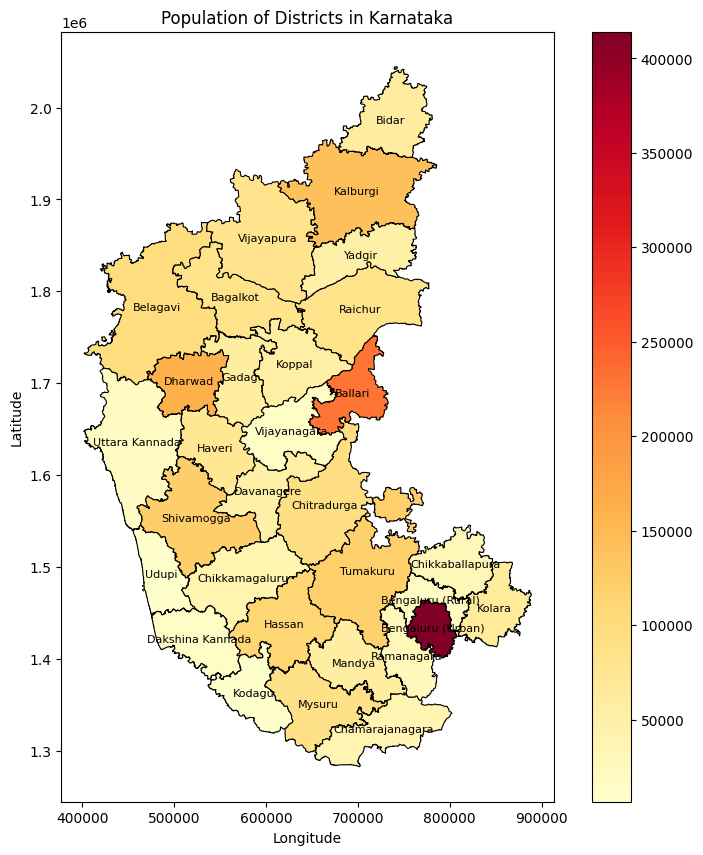

In [10]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
fig, ax=plt.subplots(figsize=(10,10))
cmap=plt.cm.get_cmap('YlOrRd')
normaliaze=colors.Normalize(vmin=gdf_merged['population'].min(), vmax=gdf_merged['population'].max())

for x,y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged['KGISDist_1']):
    ax.text(x, y, label, fontsize=8, ha='center', va='center')
gdf_districts.plot(ax=ax, column=gdf_merged['population'], cmap=cmap, norm=normaliaze, legend=True, linewidth=0.8, edgecolor='black')
ax.set_title("Population of Districts in Karnataka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [37]:

df=gpd.read_file("C:\\Users\\KARUN NAGARAJ\\Downloads\\advanced python\\District\\District.shp")
print(df)


   KGISDistri  LGD_Distri         KGISDist_1 BhuCodeDis created_us created_da  \
0          01         527           Belagavi         01       None        NaT   
1          02         524           Bagalkot         02       None        NaT   
2          03         530         Vijayapura         03       None        NaT   
3          04         538           Kalburgi         04       None        NaT   
4          05         529              Bidar         05       None        NaT   
5          06         546            Raichur         06       None        NaT   
6          07         543             Koppal         07       None        NaT   
7          08         537              Gadag         08       None        NaT   
8          09         536            Dharwad         09       None        NaT   
9          10         550     Uttara Kannada         10       None        NaT   
10         11         540             Haveri         11  SURESHBV1 2022-07-07   
11         12         528   